# 线性回归 (Linear Regression)

https://www.runoob.com/ml/ml-linear-regression.html

线性回归（Linear Regression）是机器学习中最基础且广泛应用的算法之一。

线性回归 (Linear Regression) 是一种用于预测连续值的最基本的机器学习算法，它假设目标变量 y 和特征变量 x 之间存在线性关系，并试图找到一条最佳拟合直线来描述这种关系。

$$
y = w * x + b
$$

线性回归的目标是找到最佳的 w 和 b，使得预测值 y 与真实值之间的误差最小。常用的误差函数是均方误差 (MSE)：

$$
MSE = 1/n * sum_{n}(y_i - y_pred_i)^2
$$

## 如何求解线性回归？

### 最小二乘法

最小二乘法是一种常用的求解线性回归的方法，它通过求解以下方程来找到最佳的 ( w ) 和 ( b )。

最小二乘法的目标是最小化残差平方和（RSS），其公式为：
$$
RSS = \sum_{i=1}^n(y_i - \hat y_i)^2
$$

### 梯度下降法

## 使用 Python 实现线性回归

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

生成模拟数据

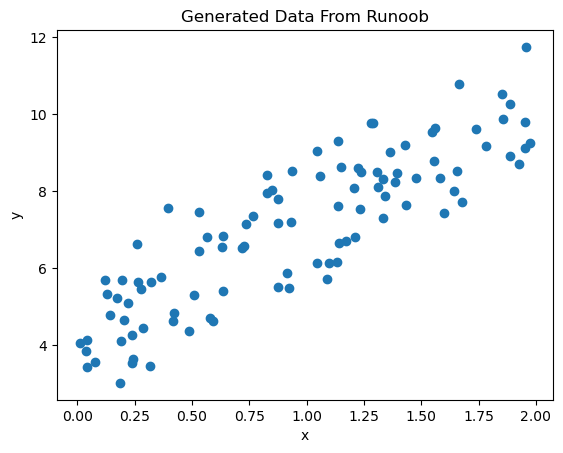

In [6]:
np.random.seed(0)
x = 2 * np.random.rand(100, 1) 
y = 4 + 3 * x + np.random.randn(100, 1)

plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data From Runoob')
plt.show()


使用 Scikit-learn 进行线性回归

斜率 (w): 2.968467510701019
截距 (b): 4.222151077447231


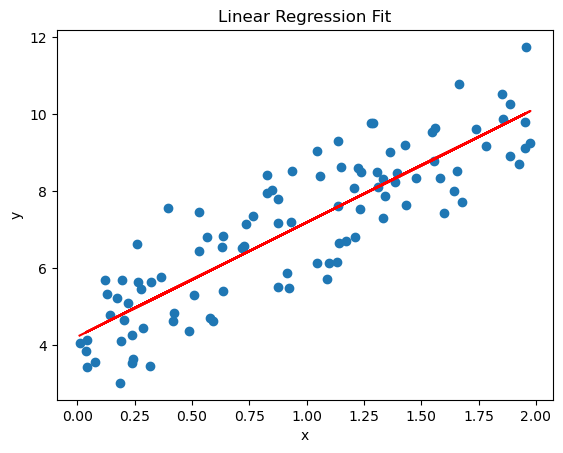

In [8]:
model = LinearRegression()
model.fit(x, y)
print(f"斜率 (w): {model.coef_[0][0]}")
print(f"截距 (b): {model.intercept_[0]}")
y_pred = model.predict(x)

# 可视化拟合结果
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.show()

我们可以使用 score() 方法来评估模型性能，返回 R^2 值。

In [10]:
score = model.score(x, y)
print("模型得分:", score)

模型得分: 0.7469629925504755


手动实现梯度下降法

手动实现的斜率 (w): 2.968467510701028
手动实现的截距 (b): 4.222151077447219


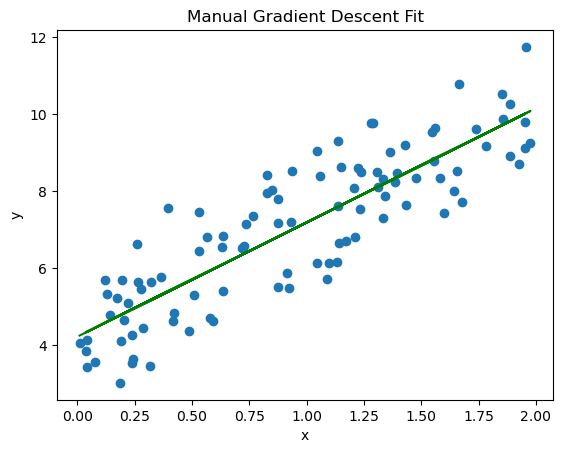

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

# 初始化参数
w = 0
b = 0
learning_rate = 0.1
n_iterations = 1000

# 梯度下降
"""
    Loss = sum(y - y_pred)^2
    
    - dLoss/y_pred = - sum 2 * (y - y_pred)
    - dy_pred/dm = x
    - dy_pred/db = 1

    所以 

    - dLoss/dw = - sum 2 * x * (y - y_pred)
    - dLoss/db = - sum 2 * (y- y_pred)
    
    使用 batch gradient descent，将所有梯度求和取平均

    为了让 Loss 减小，w 和 b 要向着梯度为负的方向。
    如果此时的梯度例如，-(2/len(x)) * np.sum(x * (y - y_pred))计算出来是正，
    说明这个位置 w 增大会让 Loss 增大，所以我们要减小 w
    所以更新的时候都是用 w - lr * dw

"""
for i in range(n_iterations):
    y_pred = w * x + b
    dw = -(2/len(x)) * np.sum(x * (y - y_pred))
    db = -(2/len(x)) * np.sum(y - y_pred)
    w = w - learning_rate * dw
    b = b - learning_rate * db

# 输出最终参数
print(f"手动实现的斜率 (w): {w}")
print(f"手动实现的截距 (b): {b}")

# 可视化手动实现的拟合结果
y_pred_manual = w * x + b
plt.scatter(x, y)
plt.plot(x, y_pred_manual, color='green')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Manual Gradient Descent Fit')
plt.show()

[3.34992059] [4.33400327]
手动实现的斜率 (w): [3.34992059]
手动实现的截距 (b): [4.33400327]


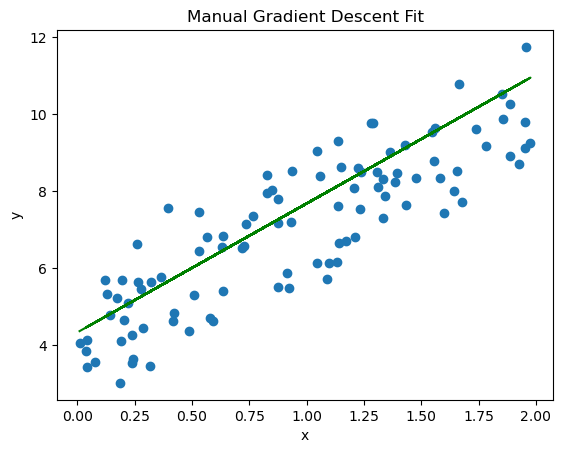

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 生成数据
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

# 初始化参数
w = 0.0
b = 0.0
learning_rate = 0.1
n_epochs = 50   # 注意：这里用 epoch，而不是 iteration

n = len(x)

# SGD
for epoch in range(n_epochs):
    indices = np.random.permutation(n)
    x_shuffled = x[indices]
    y_shuffled = y[indices]

    for i in range(n):
        xi = x_shuffled[i]
        yi = y_shuffled[i]

        # 前向
        y_pred = w * xi + b

        # 梯度（用 (y_pred - y) 形式更干净）
        dw = 2 * xi * (y_pred - yi)
        db = 2 * (y_pred - yi)

        # 更新参数
        w = w - learning_rate * dw
        b = b - learning_rate * db

print(w, b)

# 输出最终参数
print(f"手动实现的斜率 (w): {w}")
print(f"手动实现的截距 (b): {b}")

# 可视化手动实现的拟合结果
y_pred_manual = w * x + b
plt.scatter(x, y)
plt.plot(x, y_pred_manual, color='green')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Manual Gradient Descent Fit')
plt.show()